# Treinamento YOLOv8n — Detecção de Máscaras

## Objetivo

Treinar e avaliar um modelo YOLOv8n para identificar três situações:

- `mask_weared_incorrect` — pessoa usando a máscara incorretamente
- `with_mask` — pessoa com máscara
- `without_mask` — pessoa sem máscara

### Fluxo do notebook

**Dataset → análise → seleção balanceada → divisão Train/Valid/Test → `data.yaml` → treinamento → refinamento final → teste → exportação dos artefatos**

> **Observação:** o modelo final desta versão é o `best.pt` gerado no segundo treinamento (refinamento final).

## 1. Preparação do ambiente

Instalação da biblioteca principal e importação das ferramentas utilizadas no notebook.

In [ ]:
!pip install -q ultralytics

## 2. Dataset original

O dataset original é obtido em formato ZIP e extraído no ambiente do Google Colab.

Link do dataset: https://universe.roboflow.com/ai-workspace-yolo-ghcsl/medical-mask-detection/dataset/4?utm_source=chatgpt.com

In [ ]:
arquivo_zip = "/content/Medical Mask Detection.v4i.yolov8.zip"

print("ZIP selecionado:", arquivo_zip)

ZIP selecionado: /content/Medical Mask Detection.v4i.yolov8.zip


In [ ]:
import zipfile
import os

pasta_original = "/content/medical_mask"

if not os.path.exists(pasta_original):

    with zipfile.ZipFile(arquivo_zip, "r") as zip_ref:
        zip_ref.extractall(pasta_original)

    print("Dataset extraído com sucesso!")

else:

    print("A pasta já existe. Extração não necessária.")

Dataset extraído com sucesso!


In [ ]:
print(os.listdir(pasta_original))

['train', 'README.dataset.txt', 'data.yaml', 'README.roboflow.txt']


## 3. Conferência do dataset

Verificação da estrutura, das classes e da quantidade de imagens e labels.

In [ ]:
import yaml

caminho_yaml_original = "/content/medical_mask/data.yaml"

with open(caminho_yaml_original, "r") as arquivo:
    dados_original = yaml.safe_load(arquivo)

print(dados_original)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['mask_weared_incorrect', 'with_mask', 'without_mask'], 'roboflow': {'workspace': 'ai-workspace-yolo-ghcsl', 'project': 'medical-mask-detection', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ai-workspace-yolo-ghcsl/medical-mask-detection/dataset/4'}}


In [ ]:
for id_classe, nome in enumerate(dados_original["names"]):
    print(id_classe, "->", nome)

0 -> mask_weared_incorrect
1 -> with_mask
2 -> without_mask


In [ ]:
nomes_classes = {
    0: "mask_weared_incorrect",
    1: "with_mask",
    2: "without_mask"
}

print(nomes_classes)

{0: 'mask_weared_incorrect', 1: 'with_mask', 2: 'without_mask'}


In [ ]:
import os

pasta_train_original = "/content/medical_mask/train"

print(os.listdir(pasta_train_original))

['images', 'labels']


In [ ]:
pasta_images_original = "/content/medical_mask/train/images"
pasta_labels_original = "/content/medical_mask/train/labels"

quantidade_imagens = len([
    f for f in os.listdir(pasta_images_original)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

quantidade_labels = len([
    f for f in os.listdir(pasta_labels_original)
    if f.endswith(".txt")
])

print("Imagens:", quantidade_imagens)
print("Labels:", quantidade_labels)

Imagens: 14442
Labels: 14442


In [ ]:
from collections import Counter
import os

contador = Counter()

for nome_arquivo in os.listdir(pasta_labels_original):

    if not nome_arquivo.endswith(".txt"):
        continue

    caminho = os.path.join(
        pasta_labels_original,
        nome_arquivo
    )

    with open(caminho, "r") as arquivo:

        for linha in arquivo:

            partes = linha.strip().split()

            if len(partes) == 5:

                id_classe = int(partes[0])

                contador[id_classe] += 1

print("Objetos por classe:\n")

for classe in [0, 1, 2]:

    print(
        f"{classe} -> "
        f"{nomes_classes[classe]}: "
        f"{contador[classe]}"
    )

Objetos por classe:

0 -> mask_weared_incorrect: 2514
1 -> with_mask: 15388
2 -> without_mask: 6878


## 4. Seleção de imagens para balanceamento

Para reduzir o desequilíbrio entre as classes, são consideradas apenas imagens que possuem **exatamente um objeto**.

Depois, são selecionadas aleatoriamente **2.163 imagens por classe**, com `seed=42` para tornar a seleção reproduzível.

In [ ]:
import os

pasta_labels_original = "/content/medical_mask/train/labels"

imagens_uma_classe_um_objeto = {
    0: [],
    1: [],
    2: []
}

for nome_arquivo in os.listdir(pasta_labels_original):

    if not nome_arquivo.endswith(".txt"):
        continue

    caminho = os.path.join(
        pasta_labels_original,
        nome_arquivo
    )

    with open(caminho, "r") as arquivo:
        linhas = arquivo.readlines()

    linhas_validas = []

    for linha in linhas:

        partes = linha.strip().split()

        if len(partes) == 5:
            linhas_validas.append(partes)

    # Exatamente 1 objeto
    if len(linhas_validas) != 1:
        continue

    classe = int(linhas_validas[0][0])

    if classe in imagens_uma_classe_um_objeto:
        imagens_uma_classe_um_objeto[classe].append(
            nome_arquivo
        )

nomes_classes = {
    0: "mask_weared_incorrect",
    1: "with_mask",
    2: "without_mask"
}

print("Imagens com exatamente 1 objeto:\n")

for classe in [0, 1, 2]:

    print(
        f"{classe} -> "
        f"{nomes_classes[classe]}: "
        f"{len(imagens_uma_classe_um_objeto[classe])}"
    )

Imagens com exatamente 1 objeto:

0 -> mask_weared_incorrect: 2163
1 -> with_mask: 5707
2 -> without_mask: 4664


## 5. Criação do dataset balanceado


In [ ]:
import os
import shutil

pasta_balanceado_base = "/content/medical_mask_balanceado_base"

if os.path.exists(pasta_balanceado_base):
    shutil.rmtree(pasta_balanceado_base)

for classe in [0, 1, 2]:

    os.makedirs(
        f"{pasta_balanceado_base}/images/{classe}",
        exist_ok=True
    )

    os.makedirs(
        f"{pasta_balanceado_base}/labels/{classe}",
        exist_ok=True
    )

print("Pasta base criada!")

Pasta base criada!


In [ ]:
import random

random.seed(42)

selecionadas = {}

for classe in [0, 1, 2]:

    selecionadas[classe] = random.sample(
        imagens_uma_classe_um_objeto[classe],
        quantidade_por_classe
    )

    print(
        nomes_classes[classe],
        ":",
        len(selecionadas[classe])
    )

mask_weared_incorrect : 2163
with_mask : 2163
without_mask : 2163


In [ ]:
for classe in [0, 1, 2]:

    for nome_label in selecionadas[classe]:

        # Copiar label
        origem_label = os.path.join(
            pasta_labels_original,
            nome_label
        )

        destino_label = os.path.join(
            pasta_balanceado_base,
            "labels",
            str(classe),
            nome_label
        )

        shutil.copy2(
            origem_label,
            destino_label
        )

        # Procurar imagem
        nome_base = os.path.splitext(nome_label)[0]

        for extensao in [".jpg", ".jpeg", ".png"]:

            nome_imagem = nome_base + extensao

            origem_imagem = os.path.join(
                pasta_images_original,
                nome_imagem
            )

            if os.path.exists(origem_imagem):

                destino_imagem = os.path.join(
                    pasta_balanceado_base,
                    "images",
                    str(classe),
                    nome_imagem
                )

                shutil.copy2(
                    origem_imagem,
                    destino_imagem
                )

                break

print("Imagens e labels copiadas!")

Imagens e labels copiadas!


In [ ]:
import os
import shutil

pasta_dataset = "/content/medical_mask_balanceado"

if os.path.exists(pasta_dataset):
    shutil.rmtree(pasta_dataset)

for parte in ["train", "valid", "test"]:

    os.makedirs(
        f"{pasta_dataset}/{parte}/images",
        exist_ok=True
    )

    os.makedirs(
        f"{pasta_dataset}/{parte}/labels",
        exist_ok=True
    )

print("Estrutura final criada!")

Estrutura final criada!


 ## 6. Verificação da divisão

In [ ]:
random.seed(42)

for classe in [0, 1, 2]:

    lista = selecionadas[classe].copy()

    random.shuffle(lista)

    train_lista = lista[:1731]

    valid_lista = lista[1731:1731 + 216]

    test_lista = lista[1731 + 216:]

    print(
        "\n",
        nomes_classes[classe]
    )

    print("Train:", len(train_lista))
    print("Valid:", len(valid_lista))
    print("Test:", len(test_lista))


 mask_weared_incorrect
Train: 1731
Valid: 216
Test: 216

 with_mask
Train: 1731
Valid: 216
Test: 216

 without_mask
Train: 1731
Valid: 216
Test: 216


In [ ]:
def copiar_lista(lista, parte):

    for nome_label in lista:

        # -----------------------------
        # LABEL
        # -----------------------------

        origem_label = os.path.join(
            pasta_labels_original,
            nome_label
        )

        destino_label = os.path.join(
            pasta_dataset,
            parte,
            "labels",
            nome_label
        )

        shutil.copy2(
            origem_label,
            destino_label
        )

        # -----------------------------
        # IMAGEM
        # -----------------------------

        nome_base = os.path.splitext(nome_label)[0]

        encontrada = False

        for extensao in [".jpg", ".jpeg", ".png"]:

            nome_imagem = nome_base + extensao

            origem_imagem = os.path.join(
                pasta_images_original,
                nome_imagem
            )

            if os.path.exists(origem_imagem):

                destino_imagem = os.path.join(
                    pasta_dataset,
                    parte,
                    "images",
                    nome_imagem
                )

                shutil.copy2(
                    origem_imagem,
                    destino_imagem
                )

                encontrada = True
                break

        if not encontrada:
            print(
                "Imagem não encontrada:",
                nome_base
            )

In [ ]:
for classe in [0, 1, 2]:

    lista = selecionadas[classe].copy()

    random.seed(42)
    random.shuffle(lista)

    train_lista = lista[:1731]
    valid_lista = lista[1731:1947]
    test_lista = lista[1947:2163]

    copiar_lista(
        train_lista,
        "train"
    )

    copiar_lista(
        valid_lista,
        "valid"
    )

    copiar_lista(
        test_lista,
        "test"
    )

print("Divisão concluída!")

Divisão concluída!


In [ ]:
for parte in ["train", "valid", "test"]:

    pasta = f"{pasta_dataset}/{parte}/images"

    quantidade = len([
        f for f in os.listdir(pasta)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print(
        parte,
        ":",
        quantidade,
        "imagens"
    )

train : 5193 imagens
valid : 648 imagens
test : 648 imagens


In [ ]:
from collections import Counter

for parte in ["train", "valid", "test"]:

    pasta_labels = (
        f"{pasta_dataset}/{parte}/labels"
    )

    contador = Counter()

    for nome_arquivo in os.listdir(pasta_labels):

        if not nome_arquivo.endswith(".txt"):
            continue

        caminho = os.path.join(
            pasta_labels,
            nome_arquivo
        )

        with open(caminho, "r") as arquivo:

            linhas = arquivo.readlines()

        for linha in linhas:

            partes = linha.strip().split()

            if len(partes) == 5:

                contador[int(partes[0])] += 1

    print(f"\n{parte.upper()}")

    for classe in [0, 1, 2]:

        print(
            nomes_classes[classe],
            ":",
            contador[classe]
        )


TRAIN
mask_weared_incorrect : 1731
with_mask : 1731
without_mask : 1731

VALID
mask_weared_incorrect : 216
with_mask : 216
without_mask : 216

TEST
mask_weared_incorrect : 216
with_mask : 216
without_mask : 216


## 7. Configuração do YOLO

Criação do `data.yaml` usado no treinamento.

In [ ]:
data_yaml = """
path: /content/medical_mask_balanceado

train: train/images
val: valid/images
test: test/images

names:
  0: mask_weared_incorrect
  1: with_mask
  2: without_mask
"""

with open(
    f"{pasta_dataset}/data.yaml",
    "w"
) as arquivo:

    arquivo.write(data_yaml.strip())

print("data.yaml criado!")

data.yaml criado!


In [ ]:
print(
    open(
        f"{pasta_dataset}/data.yaml"
    ).read()
)

path: /content/medical_mask_balanceado

train: train/images
val: valid/images
test: test/images

names:
  0: mask_weared_incorrect
  1: with_mask
  2: without_mask


## 8. Treinamento base

Primeiro treinamento do YOLOv8n pré-treinado com o dataset balanceado.

Esse treinamento gera o checkpoint `best_mask_balanceado.pt`, que é utilizado como ponto de partida para o refinamento final.

In [ ]:
from ultralytics import YOLO

modelo_balanceado_final = YOLO(
    "yolov8n.pt"
)

print("YOLOv8n carregado!")

YOLOv8n carregado!


In [ ]:
resultado_final = modelo_balanceado_final.train(
    data="/content/medical_mask_balanceado/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs/mask_balanceado_final",
    name="yolov8n_mask_balanceado"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/medical_mask_balanceado/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_mask_balanceado, nbs=64, 

In [ ]:
import os

caminho_best = (
    "/content/runs/mask_balanceado_final/"
    "yolov8n_mask_balanceado/weights/best.pt"
)

print(
    "best.pt existe:",
    os.path.exists(caminho_best)
)

best.pt existe: True


In [ ]:
import shutil

destino_best = "/content/best_mask_balanceado.pt"

shutil.copy2(
    caminho_best,
    destino_best
)

print(
    "Modelo salvo em:",
    destino_best
)

Modelo salvo em: /content/best_mask_balanceado.pt


In [ ]:
import os

tamanho_mb = (
    os.path.getsize(destino_best)
    / (1024 ** 2)
)

print(
    f"Tamanho do modelo: {tamanho_mb:.2f} MB"
)

Tamanho do modelo: 5.96 MB


## 09. Avaliação no conjunto de teste


In [ ]:
from ultralytics import YOLO

modelo_final = YOLO(
    "/content/best_mask_balanceado.pt"
)

print("Modelo final carregado!")

Modelo final carregado!


In [ ]:
metricas_teste = modelo_final.val(
    data="/content/medical_mask_balanceado/data.yaml",
    split="test"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1063.5±549.5 MB/s, size: 36.3 KB)
val: Scanning /content/medical_mask_balanceado/test/labels... 648 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 648/648 2.1Kit/s 0.3s
val: New cache created: /content/medical_mask_balanceado/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 5.1it/s 8.1s
                   all        648        648      0.985      0.986      0.991      0.688
 mask_weared_incorrect        216        216      0.985      0.977      0.991      0.639
             with_mask        216        216      0.977      0.986      0.989      0.731
          without_mask        216        216      0.993      0.995      0.994      0.692
Speed: 1.8ms preprocess, 3.8ms inference, 0.0ms loss, 

In [ ]:
print("Precision:", metricas_teste.box.mp)
print("Recall:", metricas_teste.box.mr)
print("mAP50:", metricas_teste.box.map50)
print("mAP50-95:", metricas_teste.box.map)

Precision: 0.9849206724404315
Recall: 0.9861111111111112
mAP50: 0.9914344598720533
mAP50-95: 0.6875199998983041


In [ ]:
from google.colab import files

files.download(
    "/content/best_mask_balanceado.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

modelo_final = YOLO(
    "/content/best_mask_balanceado.pt"
)

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [ ]:
resultado_final = modelo_final.train(
    data="/content/medical_mask_balanceado/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs/mask_balanceado_final",
    name="yolov8n_mask_balanceado"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/medical_mask_balanceado/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/best_mask_balanceado.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_mas

In [ ]:
from ultralytics import YOLO

modelo = YOLO(
    "/content/runs/mask_balanceado_final/"
    "yolov8n_mask_balanceado-2/weights/best.pt"
)

metricas_teste = modelo.val(
    data="/content/medical_mask_balanceado/data.yaml",
    split="test"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 661.8±404.5 MB/s, size: 38.7 KB)
val: Scanning /content/medical_mask_balanceado/test/labels.cache... 648 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 648/648 135.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 3.6it/s 11.2s
                   all        648        648      0.994      0.985      0.993      0.708
 mask_weared_incorrect        216        216       0.99      0.972      0.994      0.676
             with_mask        216        216      0.993      0.986      0.989      0.748
          without_mask        216        216      0.999      0.995      0.995        0.7
Speed: 3.2ms preprocess, 4.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/v

In [ ]:
import shutil
import os

origem = (
    "/content/runs/mask_balanceado_final/"
    "yolov8n_mask_balanceado-2/weights/best.pt"
)

destino = "/content/best_mask_balanceado_final.pt"

shutil.copy2(origem, destino)

print("Modelo salvo em:")
print(destino)
print("Existe?", os.path.exists(destino))

Modelo salvo em:
/content/best_mask_balanceado_final.pt
Existe? True


In [ ]:
from google.colab import files

files.download("/content/best_mask_balanceado_final.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/medical_mask_balanceado/test/images/000005237_127-jpg_jpg.rf.f92bfb60b49bef568f26b2e57649731d.jpg: 640x640 1 without_mask, 10.0ms
Speed: 1.4ms preprocess, 10.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


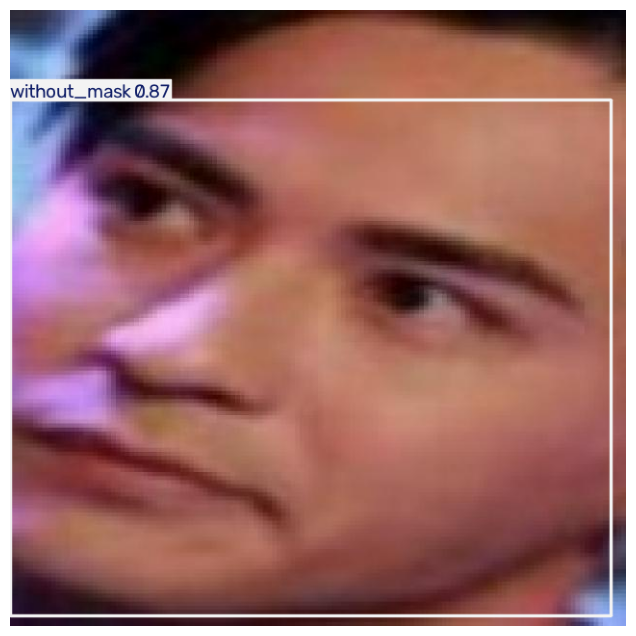

Imagem testada: 000005237_127-jpg_jpg.rf.f92bfb60b49bef568f26b2e57649731d.jpg


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

pasta_teste = "/content/medical_mask_balanceado/test/images"

# pega a primeira imagem encontrada
arquivos = [
    f for f in os.listdir(pasta_teste)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

imagem_path = os.path.join(pasta_teste, arquivos[0])

# faz a previsão
resultado = modelo(imagem_path, conf=0.25)

# imagem com as caixas
imagem_resultado = resultado[0].plot()

# OpenCV usa BGR, matplotlib usa RGB
imagem_resultado = cv2.cvtColor(imagem_resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(imagem_resultado)
plt.axis("off")
plt.show()

print("Imagem testada:", arquivos[0])


image 1/1 /content/medical_mask_balanceado/test/images/000000003_127-jpg_jpg.rf.ff7218ac64961d4a5a9763fbabefb98d.jpg: 640x640 1 without_mask, 48.7ms
Speed: 1.1ms preprocess, 48.7ms inference, 11.9ms postprocess per image at shape (1, 3, 640, 640)


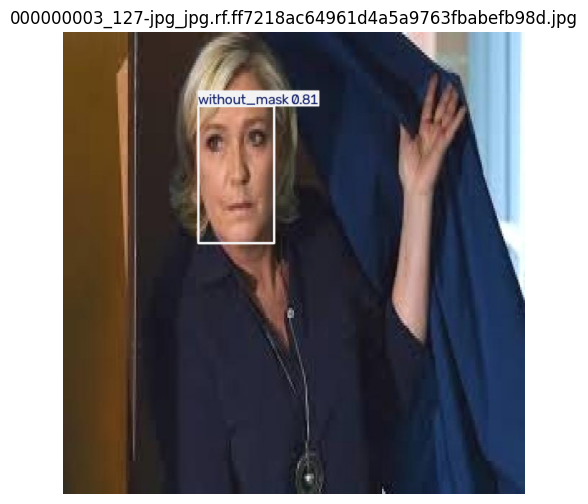


image 1/1 /content/medical_mask_balanceado/test/images/000000018_127-jpg_jpg.rf.bff87cd64cdf269eb714a11e99e0bf14.jpg: 640x640 1 with_mask, 10.4ms
Speed: 1.2ms preprocess, 10.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


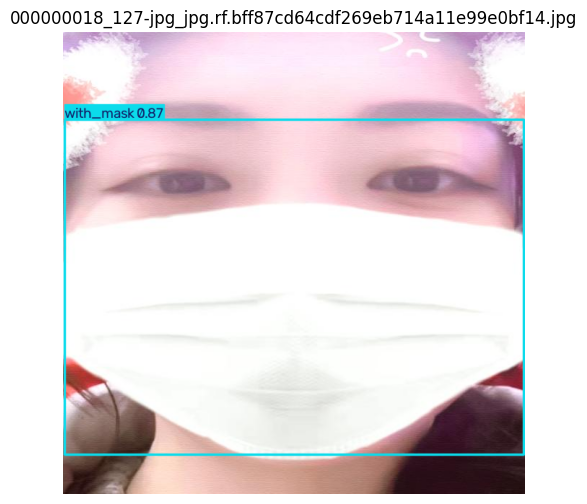


image 1/1 /content/medical_mask_balanceado/test/images/000000034_127-jpg_jpg.rf.d912b2fcbe0785abd848917b9a3cc383.jpg: 640x640 1 with_mask, 32.5ms
Speed: 2.0ms preprocess, 32.5ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


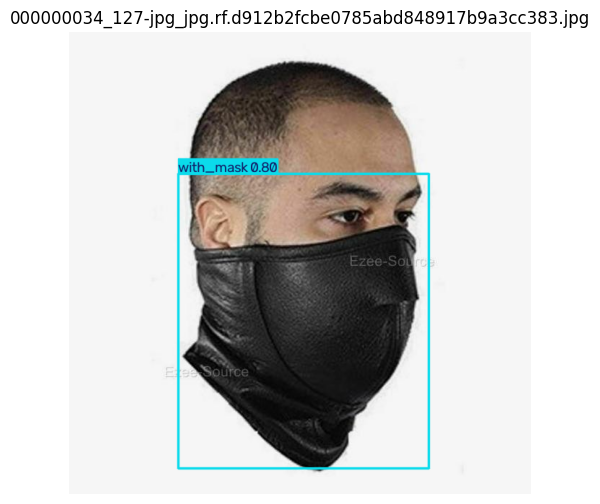


image 1/1 /content/medical_mask_balanceado/test/images/000000063_127-jpg_jpg.rf.eae042539680eeb98dfc793614158748.jpg: 640x640 1 without_mask, 22.5ms
Speed: 3.9ms preprocess, 22.5ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 640)


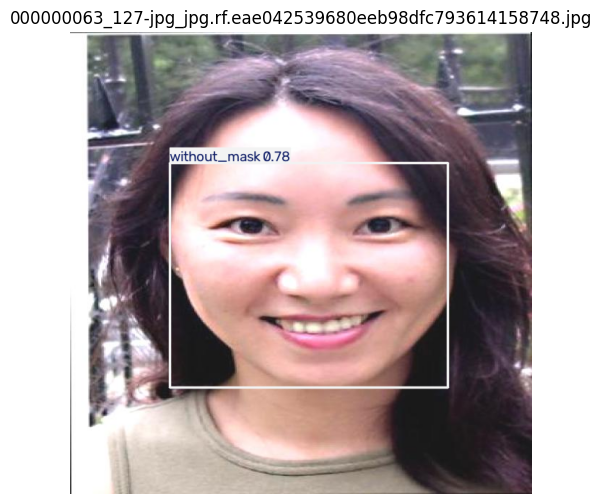


image 1/1 /content/medical_mask_balanceado/test/images/000000118_127-jpg_jpg.rf.7a46b8915e06bceab3e5d06e71c2d25a.jpg: 640x640 1 without_mask, 40.2ms
Speed: 5.0ms preprocess, 40.2ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 640)


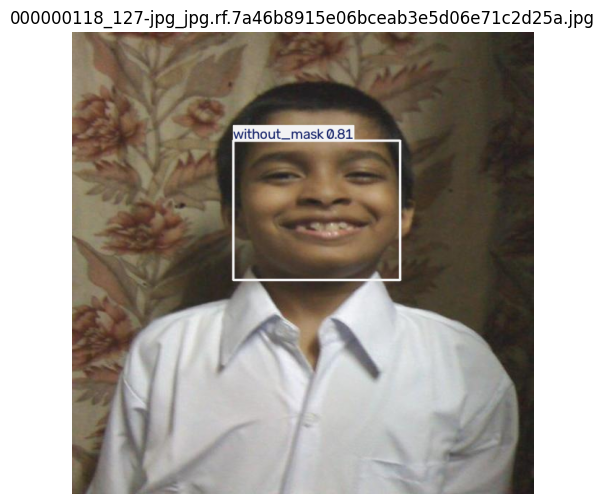


image 1/1 /content/medical_mask_balanceado/test/images/000000132_127-jpg_jpg.rf.54e3010215e4b5f91b083abc24d1ba35.jpg: 640x640 1 with_mask, 12.6ms
Speed: 1.2ms preprocess, 12.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


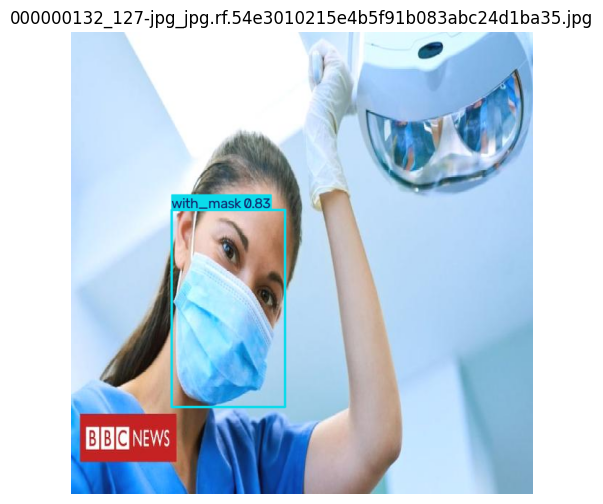


image 1/1 /content/medical_mask_balanceado/test/images/000000135_127-jpg_jpg.rf.761157bec5fa78a5b138ddadce8b890c.jpg: 640x640 1 with_mask, 12.5ms
Speed: 1.4ms preprocess, 12.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


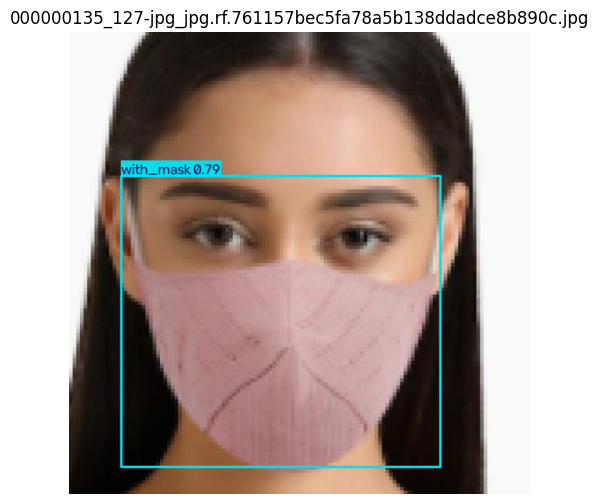


image 1/1 /content/medical_mask_balanceado/test/images/000000196_127-jpg_jpg.rf.f796c5144854123a8a44cc26b9b63446.jpg: 640x640 1 without_mask, 33.4ms
Speed: 1.2ms preprocess, 33.4ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 640)


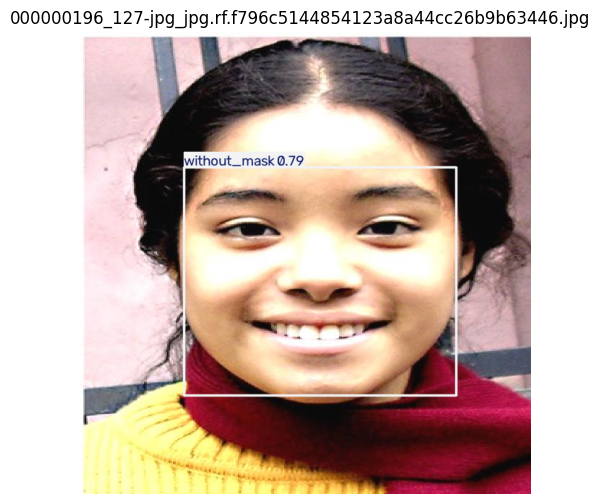


image 1/1 /content/medical_mask_balanceado/test/images/000000202_127-jpg_jpg.rf.514506f9400baf9fd9ab0d4bf1ae0fdf.jpg: 640x640 1 with_mask, 13.7ms
Speed: 1.1ms preprocess, 13.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


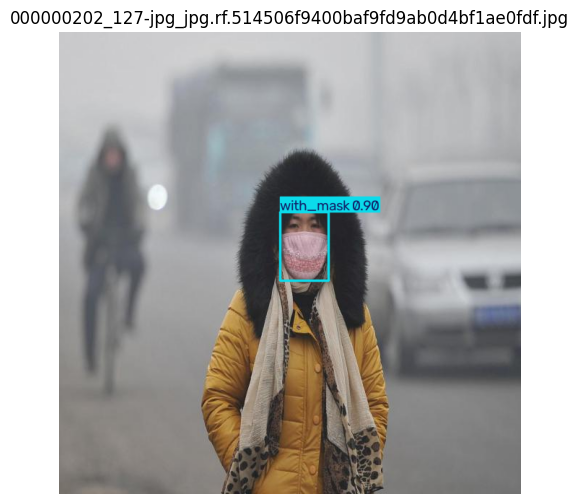


image 1/1 /content/medical_mask_balanceado/test/images/000000211_127-jpg_jpg.rf.089c27ca2524cf1bbb2c210d7afdc951.jpg: 640x640 1 with_mask, 12.1ms
Speed: 3.5ms preprocess, 12.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


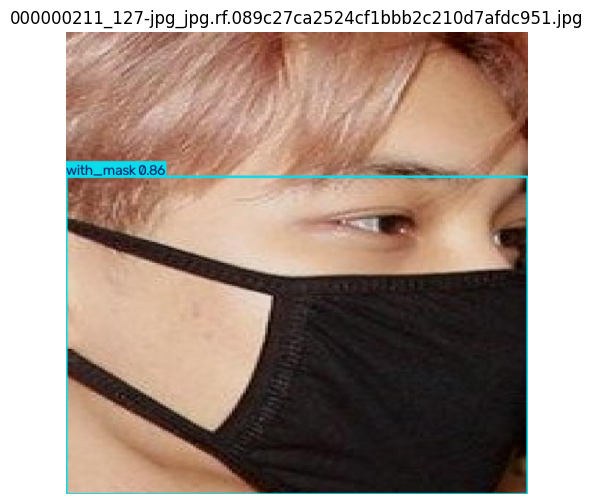


image 1/1 /content/medical_mask_balanceado/test/images/000000217_127-jpg_jpg.rf.b6c6d9f7b72fe32dfb2e20eb0fb33c8a.jpg: 640x640 1 with_mask, 25.0ms
Speed: 1.2ms preprocess, 25.0ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)


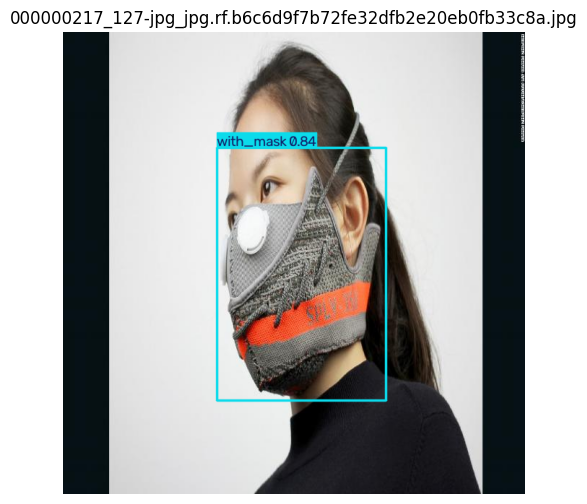


image 1/1 /content/medical_mask_balanceado/test/images/000000258_127-jpg_jpg.rf.617ee4adc214f1b66b0091c7d6c4e354.jpg: 640x640 1 without_mask, 14.5ms
Speed: 1.2ms preprocess, 14.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


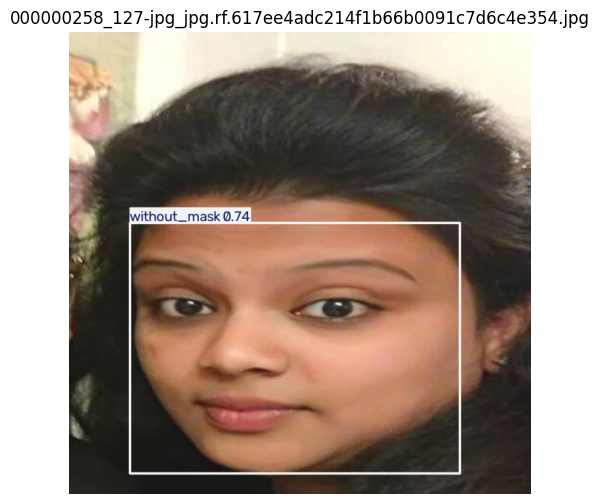

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

pasta_teste = "/content/medical_mask_balanceado/test/images"

arquivos = [
    f for f in os.listdir(pasta_teste)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

arquivos = sorted(arquivos)[:12]

for nome in arquivos:

    caminho = os.path.join(pasta_teste, nome)

    resultado = modelo(caminho, conf=0.25)

    imagem = resultado[0].plot()
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(imagem)
    plt.title(nome)
    plt.axis("off")
    plt.show()


0: 640x480 1 with_mask, 9.8ms
Speed: 4.2ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


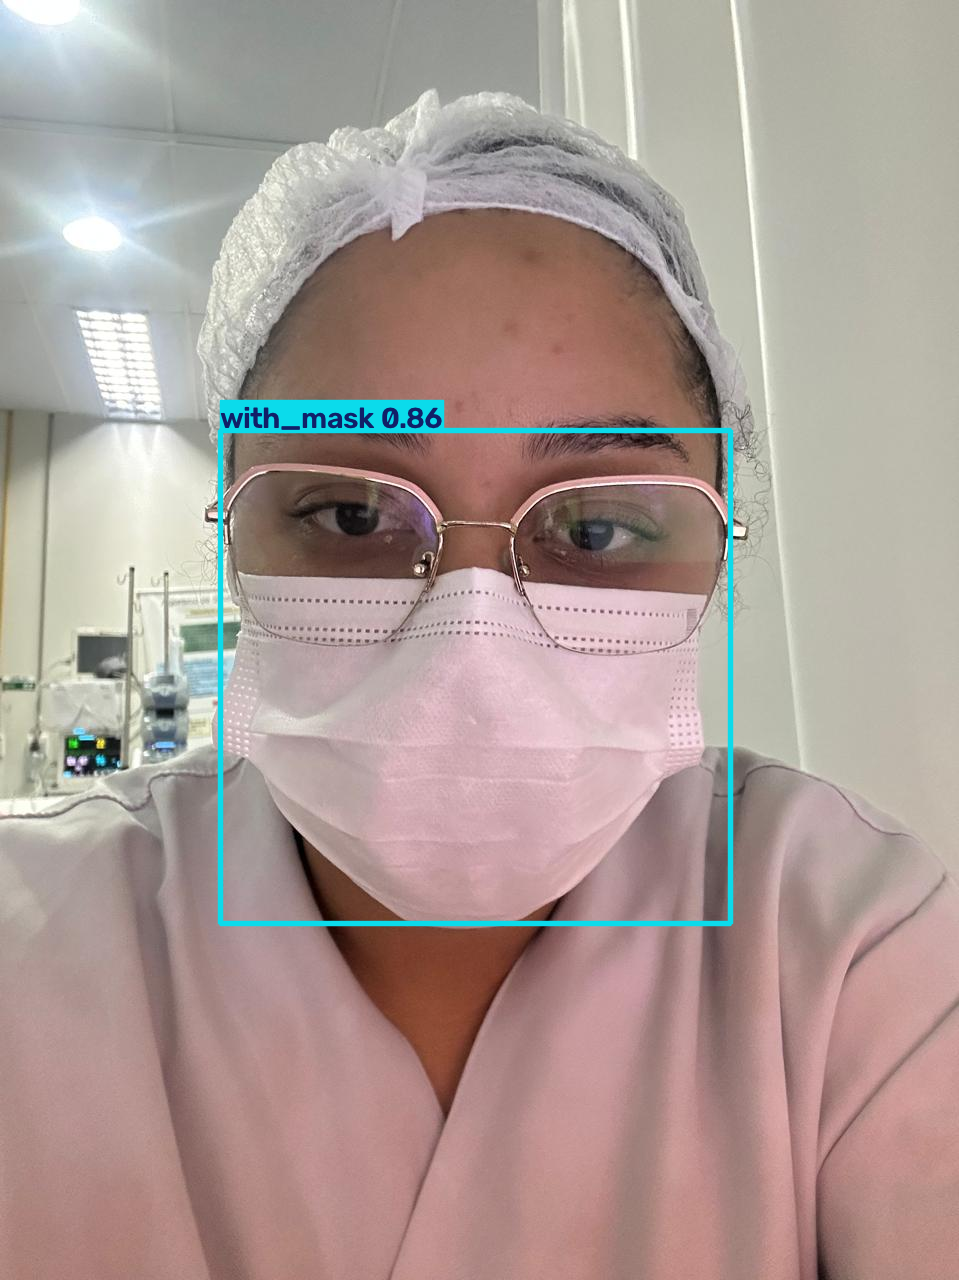

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2
import os

# Caminho do modelo
modelo = YOLO("best_mask_balanceado_final.pt")

# Caminho da imagem
imagem = cv2.imread("img.png")

if imagem is None:
    print("Erro: não foi possível abrir a imagem.")
else:
    # Faz a previsão
    resultado = modelo(imagem, conf=0.25)

    # Desenha as caixas
    imagem_resultado = resultado[0].plot()

    # Mostra no Colab
    cv2_imshow(imagem_resultado)